In [48]:
from process_bin_root import *
from modelling_data import ajuste_lineal
from sklearn.cluster import DBSCAN
import ROOT

## Carga de datos

Defino las carpetas y paths a analizar

In [49]:
folders = ["20251125-protonterapia", "20251126-pterapia", "20251127-pterapia"]
path = lambda folder: f"/home/lexi/Documentos/Datos CNEA/CAC_Protonterapia/2025_11_protonterapia/{folder}/DAQ/"

Chequeo sanidad de los datos en la carpeta y me quedo con aquellos que tienen dos canales (BIN_sanity es lo que tarda más, ejecutar una vez)

In [50]:
folder = folders[2]
BIN_check = BIN_sanity(path(folder))

In [51]:
for tipo in BIN_check:
    print('Hay', len(BIN_check[tipo]), 'archivos', tipo)

Hay 6 archivos empty
Hay 3 archivos broken
Hay 52 archivos 1_ch
Hay 28 archivos 2_ch


In [52]:
BINs_2ch = BIN_check['2_ch']
BINs_2ch

['20251127_run_alpha_11',
 '20251127_run_alpha_3',
 '20251127_run_alpha_4',
 '20251127_run_alpha_5',
 '20251127_run_alpha_6',
 '20251127_run_protons_18MeV_1',
 '20251127_run_protons_18MeV_1lexan_1',
 '20251127_run_protons_19MeV_1',
 '20251127_run_protons_19MeV_rf9_1',
 '20251127_run_protons_19MeV_rf_1',
 '20251127_run_protons_20MeV_1',
 '20251127_run_protons_20MeV_2',
 '20251127_run_protons_20MeV_3',
 '20251127_run_protons_20MeV_rf9_1',
 '20251127_run_protons_20MeV_rf_1',
 '20251127_run_protons_rf9_18MeV_1',
 '20251127_run_protons_rf9_18MeV_2',
 '20251127_run_protons_rf9_18MeV_3',
 '20251127_run_protons_rf9_18MeV_4',
 '20251127_run_protons_rf9_18MeV_5',
 '20251127_run_protons_rf9_18MeV_6',
 '20251127_run_protons_rf9_1lexan_18MeV_1',
 '20251127_run_protons_rf_18MeV_1',
 '20251127_run_protons_rf_18MeV_2',
 '20251127_run_protons_rf_1lexan_18MeV_1',
 '20251127_run_protons_rf_tapa_18MeV_1',
 '20251127_run_protons_rf_tapa_18MeV_2',
 '20251127_run_protons_tapa_18MeV_1']

In [ ]:
run =  '20251127_run_protons_tapa_18MeV_1'
pathBIN = glob.glob(path(folder) + run + '/RAW/*.BIN')[0]
print('Analizando...\n', pathBIN)

Analizando...
 /home/lexi/Documentos/Datos CNEA/CAC_Protonterapia/2025_11_protonterapia/20251127-pterapia/DAQ/20251127_run_protons_rf_tapa_18MeV_1/RAW/SDataR_20251127_run_protons_rf_tapa_18MeV_1.BIN


In [54]:
dfBIN = bin_to_df(pathBIN)

In [55]:
pathROOT = glob.glob(path(folder) + run + '/RAW/*.root')[0]
rootfile = ROOT.TFile.Open(pathROOT)

In [56]:
dfROOT = (
    hist_root(rootfile)
    .rename(columns = {
        'bins_center': 'Energy',
        'counts': 'Counts'
        })
)

In [57]:
dfROOT_filt = filter_hist(dfROOT, counts_min= 1, ch_min=100, ch_max= 700)

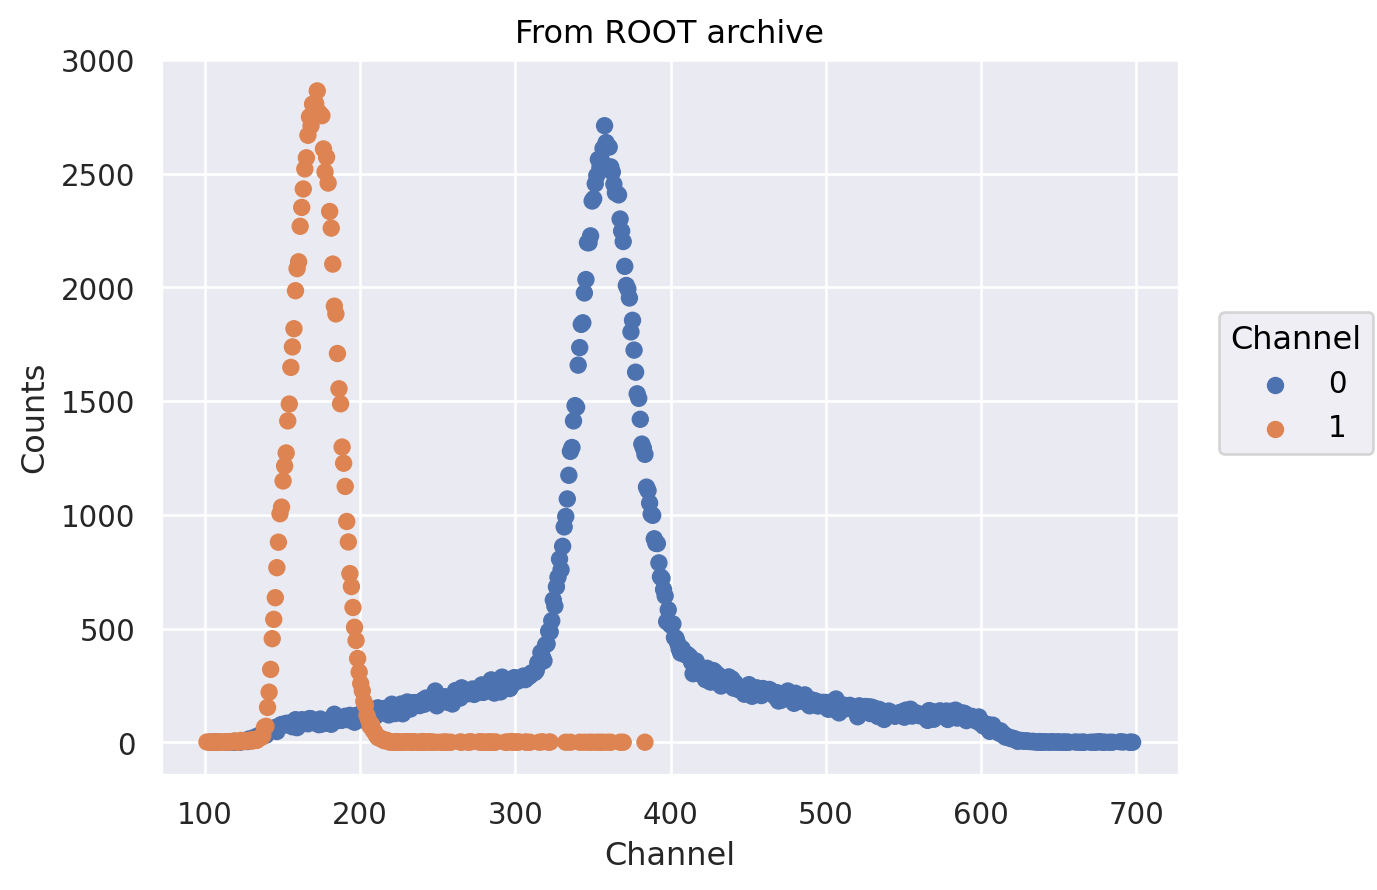

In [58]:
(
    so.Plot(data = dfROOT_filt, x = 'Energy', y = 'Counts', color = dfROOT_filt.Channel.astype(str))
    .add(so.Dot())
    .label(x = 'Channel', y = 'Counts', title = 'From ROOT archive')
)



## Histogramas por canal

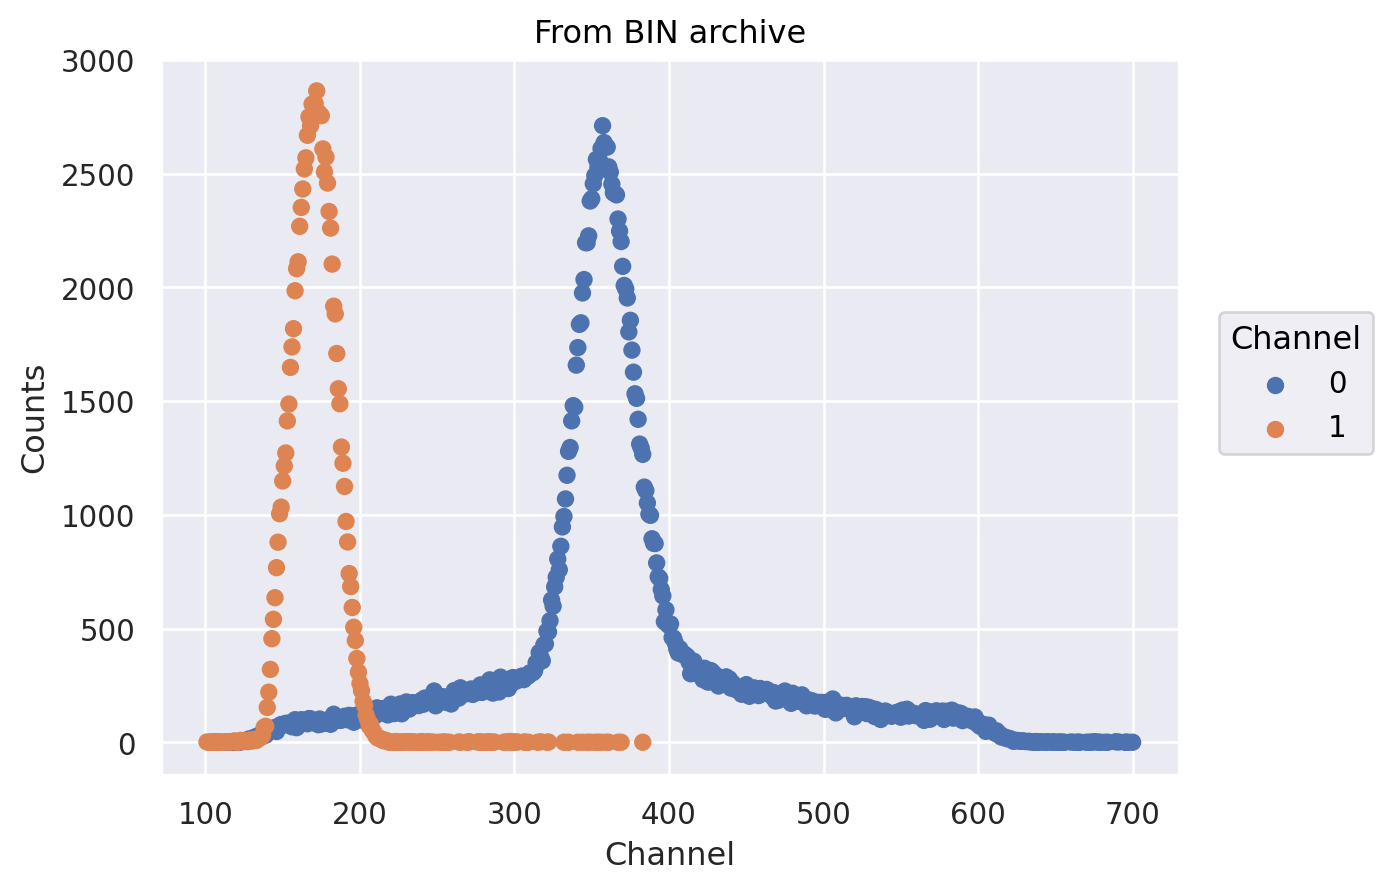

In [59]:
dfBIN_hist = hist_bin(pathBIN)
dfBIN_hist_filt = filter_hist(dfBIN_hist, counts_min= 1, ch_min=100, ch_max= 700)


(
    so.Plot(data = dfBIN_hist_filt, x = 'Energy', y = 'Counts', color = dfBIN_hist_filt.Channel.astype(str))
    .add(so.Dot())
    .label(x = 'Channel', y = 'Counts', title = 'From BIN archive')
)

## Calibración

In [60]:
df_coef = pd.read_csv('coef_calib_energia.csv')
df_coef

,det,m,b,R2
0,0,0.008826,2.339336,0.999544
1,1,0.022521,2.436750,0.999876


In [61]:
df_coef_LISE = pd.read_csv('coef_calib_energia_LISE.csv')
df_coef_LISE

,det,m,b,R2
0,0,0.010157,0.949446,0.999791
1,1,0.025912,1.062250,0.999675


In [62]:
dfROOT = apply_calibration_en(dfROOT, df_coef, move_old_to = 'Energy_Ch')
dfBIN = apply_calibration_en(dfBIN, df_coef, move_old_to = 'Energy_Ch')

In [63]:
dfROOT = apply_calibration_en(dfROOT, df_coef_LISE, col = 'Energy_Ch', new = 'Energy_LISE')
dfBIN = apply_calibration_en(dfBIN, df_coef_LISE, col = 'Energy_Ch', new = 'Energy_LISE')

## Coincidencias

In [64]:
df_coinc = df_coincidences(dfBIN, det_0 = 0, det_1 = 1, window_ns = 600, Energy_col= ['Energy_Ch', 'Energy', 'Energy_LISE'])

In [65]:
df_coinc_wo_0 = df_coinc[(df_coinc.Energy_DET0 > 0) & (df_coinc.Energy_DET1 > 0)]
df_coinc_wo_0.head()

,i,j,Energy_Ch_DET0,Energy_Ch_DET1,Energy_DET0,Energy_DET1,Energy_LISE_DET0,Energy_LISE_DET1
0,2,0,353,176,5.454845,6.400412,4.534882,5.622749
1,3,1,375,166,5.649013,6.175204,4.758337,5.363630
2,5,2,359,169,5.507800,6.242766,4.595824,5.441366
3,7,3,353,157,5.454845,5.972516,4.534882,5.130423
4,8,4,353,180,5.454845,6.490495,4.534882,5.726397


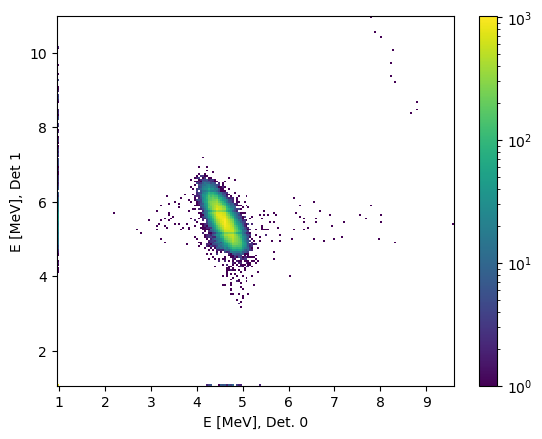

In [66]:
graph_coincidences(df_coinc_wo_0, det_0 = 0, det_1 = 1, Energy_col= 'Energy_LISE')

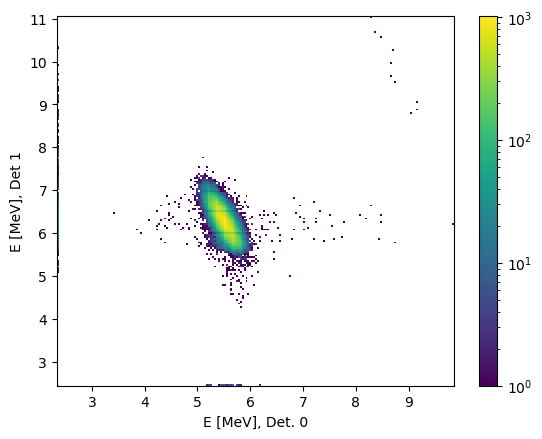

In [67]:
graph_coincidences(df_coinc_wo_0, det_0 = 0, det_1 = 1, Energy_col= 'Energy')